In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from google.colab import files
from io import BytesIO
from PIL import Image

In [2]:
model = keras.applications.VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:

uploaded = files.upload()

Saving Panda.jpg to Panda.jpg


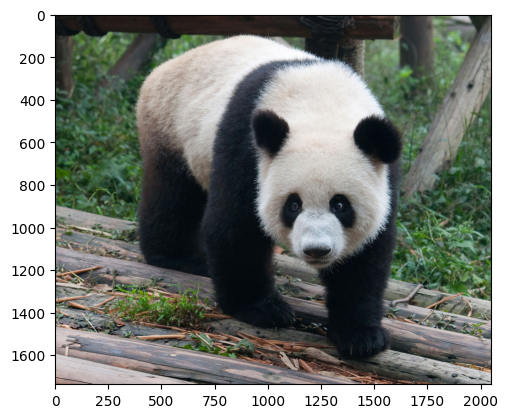

In [4]:
img = Image.open(BytesIO(uploaded['Panda.jpg']))
plt.imshow(img)

In [6]:
filename = next(iter(uploaded))
img = Image.open(BytesIO(uploaded[filename])).convert('RGB')   # 3 kanal təmin edir
img = img.resize((224, 224))                                    # ölçünü dəyiş

# приводим к входному формату VGG-сети
img = np.array(img)
x = keras.applications.vgg16.preprocess_input(img)
print(x.shape)
x = np.expand_dims(x, axis=0)
print(x.shape)

(224, 224, 3)
(1, 224, 224, 3)


In [7]:
# прогоняем через сеть
res = model.predict(x)
print(np.argmax(res))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step
388


In [8]:
from tensorflow.keras.applications.vgg16 import decode_predictions

# ən yüksək 5 proqnoz
preds = decode_predictions(res, top=5)[0]
for class_id, name, prob in preds:
    print(f"{name:25s} {prob*100:.2f}%  ({class_id})")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
giant_panda               99.98%  (n02510455)
lesser_panda              0.02%  (n02509815)
brown_bear                0.00%  (n02132136)
American_black_bear       0.00%  (n02133161)
sloth_bear                0.00%  (n02134418)
